In [1]:
import torch
from torch import nn
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import wandb
import os
import yaml
import random
import copy
import numpy as np

from custom_dataset import CustomDataset, CustomDatasetPCAtimeseries, CustomDatasetQuantileTimeseries
from model_v2 import TransformerBasedRegressor
from training_module import TrainEvaluateModel
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from loss import hurdle_nll_loss

In [ ]:
config = {
    "d_model": 256,
    "d_out": 256,
    "drop_rate": 0.2,
    "context_length": 162,
    "num_layers": 3,
    "epochs": 400,
    "model_name": "scattering_regression_v2_rfi_removed.pth",
    "architecture": "MultimodalTransformerLogNormal",
    "learning_rate": 0.0001,
    "weight_decay": 0.09,
    "nhead": 4,
    "batch_size": 32
}

In [4]:
# Train dir and test dir 
train_dir = "../ondemand/data/train"
val_dir = "../ondemand/data/val"
tar_dir = "../ondemand/data/scattering_times.csv"

In [ ]:
# Define transformation
transforms_train = v2.Compose([
    v2.Lambda(lambda x: (x - x.min()) / (x.max() - x.min())),
    v2.Lambda(lambda x: torch.roll(x, shifts=random.randint(-60, 10), dims=-1))
])
# Define transformation
transforms_test = v2.Compose([
    v2.Lambda(lambda x: (x - x.min()) / (x.max() - x.min())),
])

In [ ]:
train_dl = DataLoader(CustomDataset(train_dir, tar_dir, transforms_train, add_noise_data=False),
                      batch_size=config["batch_size"], 
                      shuffle=True, num_workers=16,
                      pin_memory=True)
val_dl = DataLoader(CustomDataset(val_dir, tar_dir, add_noise_data=False), batch_size=config["batch_size"])

In [6]:
# train_dl = DataLoader(CustomDatasetPCAtimeseries(train_dir, tar_dir, transforms_train), batch_size=config["batch_size"], shuffle=True, num_workers=8, pin_memory=True)
# val_dl = DataLoader(CustomDatasetPCAtimeseries(val_dir, tar_dir), batch_size=config["batch_size"])
# train_dl = DataLoader(CustomDatasetQuantileTimeseries(train_dir, tar_dir, transforms_train, quantile=0.99), batch_size=config["batch_size"], shuffle=True, num_workers=8, pin_memory=True)
# val_dl = DataLoader(CustomDatasetQuantileTimeseries(val_dir, tar_dir, quantile=0.99), batch_size=config["batch_size"])

In [7]:
# run_wandb = wandb.init(project="Scattering Timescale Estimation With Multimodal Transformer", config=config, mode="offline")

In [8]:
model = TransformerBasedRegressor(cfg=config)

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [11]:
model.to(device)

TransformerBasedRegressor(
  (ts_proj): Linear(in_features=1, out_features=256, bias=True)
  (drop_emb): Dropout(p=0.2, inplace=False)
  (pos_emb): Embedding(162, 256)
  (layer_norm_img): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (layer_norm_ts): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (transformer): MultimodelTransformerEncoder(
    (img_transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1

In [ ]:
base_learning_rate = config["learning_rate"]
optimizer = torch.optim.AdamW(model.parameters(), lr=base_learning_rate, weight_decay=config["weight_decay"])

In [30]:
epochs = config["epochs"]

In [31]:
print(device)

cuda


In [32]:
train_evaluate = TrainEvaluateModel(model=model, optimizer=optimizer, loss_fn=hurdle_nll_loss, device=device)

In [ ]:
train_loss_per_epoch = []
validation_loss_per_epoch = []
best_val_loss_epoch = 0
best_loss = torch.inf
for epoch in range(1, epochs+1):
    print(f"Epoch: {epoch:3d}")
    print("----------")
    train_loss = train_evaluate.train_model(dataloader=train_dl)
    train_loss_per_epoch.append(train_loss)
    eval_loss = train_evaluate.evaluate_model(dataloader=val_dl)
    validation_loss_per_epoch.append(eval_loss)

    
    
    if eval_loss < best_loss:
        best_val_loss_epoch = epoch
        best_loss = eval_loss
        print(f"Saving the best model in epoch: {epoch}...")
        torch.save(model.state_dict(), "trained_models/no_noise_data_included/" + config["model_name"])
    # run_wandb.log({"training_loss": train_loss, "validation_loss": eval_loss})
    print(f"Training Loss: {train_loss:.5f} || Validation Loss: {eval_loss:.5f}\n")

Epoch:   1
----------
Saving the best model in epoch: 1...
Training Loss: 2.37296 || Validation Loss: 2.21395

Epoch:   2
----------
Saving the best model in epoch: 2...
Training Loss: 2.26068 || Validation Loss: 2.14687

Epoch:   3
----------
Saving the best model in epoch: 3...
Training Loss: 2.22614 || Validation Loss: 2.13131

Epoch:   4
----------
Saving the best model in epoch: 4...
Training Loss: 2.21806 || Validation Loss: 2.11703

Epoch:   5
----------
Training Loss: 2.19195 || Validation Loss: 2.12387

Epoch:   6
----------
Training Loss: 2.18637 || Validation Loss: 2.33939

Epoch:   7
----------
Saving the best model in epoch: 7...
Training Loss: 2.10269 || Validation Loss: 1.95169

Epoch:   8
----------
Training Loss: 2.09916 || Validation Loss: 2.07561

Epoch:   9
----------
Saving the best model in epoch: 9...
Training Loss: 2.06041 || Validation Loss: 1.92687

Epoch:  10
----------
Saving the best model in epoch: 10...
Training Loss: 2.05960 || Validation Loss: 1.85843



In [ ]:
#Save the final model
torch.save(model.state_dict(), "trained_models/scattering_regression_v2_1.pth")

In [34]:
def predict_scattering_timescale(model, *inputs):
    model.eval()
    with torch.inference_mode():
        p0, mu, sigma = model(*inputs)

    # Expected τ (mixture mean)
    tau_mean_pos = torch.exp(mu + 0.5 * sigma**2)
    tau_pred = (1 - p0) * tau_mean_pos

    # Conditional median and 95% CI (if τ > 0)
    tau_med = torch.exp(mu)
    ci95_lower = torch.exp(mu - 1.96 * sigma)
    ci95_upper = torch.exp(mu + 1.96 * sigma)
    ci95 = torch.cat([ci95_lower, ci95_upper], dim=-1)

    return tau_med, p0, tau_med, ci95

In [54]:
target = []
prediction = []
p_0 = []
for img, ts, tar in  test_dl:
    # if tar.item() > 50:
    #     continue
    tau_pred, p0, tau_med, ci95 = predict_scattering_timescale(model, img.to(device), ts.to(device))
    if p0.item() >= 0.5:
        tau_pred = torch.tensor(0.0)
    # if tau_pred.item() < 1:
    #     tau_pred = torch.tensor(0)
    target.append(tar.item())
    prediction.append(tau_pred.item())
    # print(ci95.squeeze().tolist(), '---->', round(tar.item(), 2), '--->', round(tau_pred.item(), 2))

In [55]:
# for t, p in zip(target, prediction):
#     print(round(t,2), '---->', round(p,2))

Text(0, 0.5, 'ML Model Values')

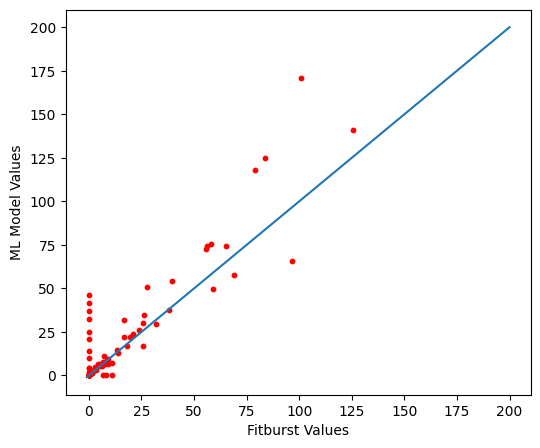

In [56]:
fig = plt.figure(figsize=(6,5))
plt.scatter(target, prediction, s=10, c='red')
plt.plot((-1, 200), (-1, 200))
plt.xlabel('Fitburst Values')
plt.ylabel('ML Model Values')

In [57]:
r2_score_ = r2_score(prediction, target)

In [58]:
r2_score_

0.8189653249400315

In [ ]:
run_wandb.log({'R^2': r2_score_, 'Model saved epoch': best_val_loss_epoch})

In [ ]:
run_wandb.finish()